In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("drug200.csv")
df.head()

,Unnamed: 0,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,0,23,F,HIGH,HIGH,25.355,drugY
1,1,47,M,LOW,HIGH,13.093,drugC
2,2,47,M,LOW,HIGH,10.114,drugC
3,3,28,F,NORMAL,HIGH,7.798,drugX
4,4,61,F,LOW,HIGH,18.043,drugY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   200 non-null    int64  
 1   Age          200 non-null    int64  
 2   Sex          200 non-null    object 
 3   BP           200 non-null    object 
 4   Cholesterol  200 non-null    object 
 5   Na_to_K      200 non-null    float64
 6   Drug         200 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 11.1+ KB


In [4]:
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex']) 
df['BP'] = label_encoder.fit_transform(df['BP'])
df['Cholesterol'] = label_encoder.fit_transform(df['Cholesterol']) 
df

,Unnamed: 0,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,0,23,0,0,0,25.355,drugY
1,1,47,1,1,0,13.093,drugC
2,2,47,1,1,0,10.114,drugC
3,3,28,0,2,0,7.798,drugX
4,4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...,...
195,195,56,0,1,0,11.567,drugC
196,196,16,1,1,0,12.006,drugC
197,197,52,1,2,0,9.894,drugX
198,198,23,1,2,1,14.020,drugX


In [5]:
df.isnull().sum()

Unnamed: 0     0
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [6]:
custom_map = {'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
df['Drug_num'] = df['Drug'].map(custom_map)
df

,Unnamed: 0,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_num
0,0,23,0,0,0,25.355,drugY,4
1,1,47,1,1,0,13.093,drugC,2
2,2,47,1,1,0,10.114,drugC,2
3,3,28,0,2,0,7.798,drugX,3
4,4,61,0,1,0,18.043,drugY,4
...,...,...,...,...,...,...,...,...
195,195,56,0,1,0,11.567,drugC,2
196,196,16,1,1,0,12.006,drugC,2
197,197,52,1,2,0,9.894,drugX,3
198,198,23,1,2,1,14.020,drugX,3


In [7]:
df.drop('Drug',axis=1).corr()['Drug_num']

Unnamed: 0    -0.088400
Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

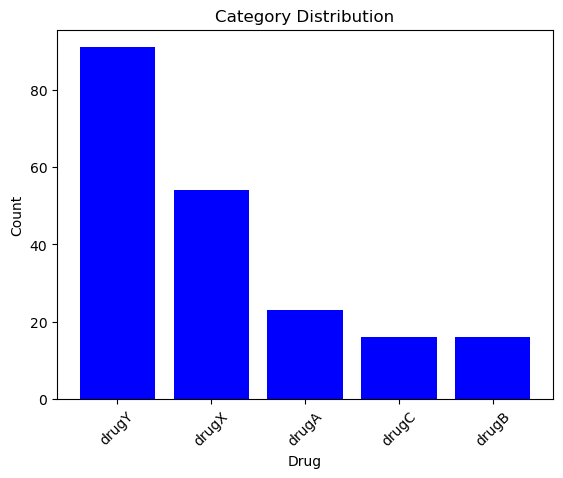

In [8]:
category_counts = df['Drug'].value_counts()

plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)  # Rotate labels for better readability if needed
plt.show()

In [9]:
y = df['Drug']
X = df.drop(['Drug','Drug_num'], axis=1)

In [10]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32)

In [20]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)

In [17]:
drugTree.fit(X_trainset,y_trainset)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
tree_predictions = drugTree.predict(X_testset)

In [19]:
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

Decision Trees's Accuracy:  0.9833333333333333


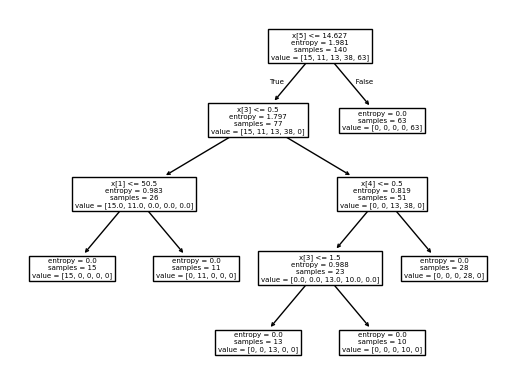

In [15]:
plot_tree(drugTree)
plt.show()